<a href="https://colab.research.google.com/github/gapalfaro-cmyk/Proyecto-de-fin-de-modulo-7---Alfaro-Badillo-Cruz-Perez-Rupit/blob/main/Programacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea 1

# **Sección 1:  SGD y variantes en regresión logística**

## Descripción del problema
Clasificar imágenes de sangre (BloodMNIST) en los 8 tipos que existen.

## Metodología
### 1. SGD y SGD + Momentum

# Resultados (y Programación)

*   Instalación de Librerías
*   EDA
*   Regresión logística SGD (Vainilla)
*   Regresión logística SGD + Momentum
*   Comparativo de los modelos

In [21]:
# Librerías necesarias para el código
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
!pip install medmnist
from medmnist import BloodMNIST
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import log_loss, accuracy_score, classification_report, confusion_matrix
from sklearn import metrics
from sklearn.model_selection import train_test_split
import time
import tensorflow as tf
from tensorflow.keras import layers, models

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.13/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

I0000 00:00:1785886728.025329   49210 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785886728.857598   49210 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [5]:
# Bases de datos
train_dataset = BloodMNIST(split='train', download=True)
val_dataset = BloodMNIST(split='val', download=True)
test_dataset = BloodMNIST(split='test', download=True)

# EDA

In [6]:
# Tamaño o número de registros de la base de imágenes
print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")
print(f"Total: {len(train_dataset) + len(val_dataset) + len(test_dataset)}")

Train: 11959
Val:   1712
Test:  3421
Total: 17092


Frecuencia de imágenes por etiqueta:
0     852
1    2181
2    1085
3    2026
4     849
5     993
6    2330
7    1643
Name: count, dtype: int64


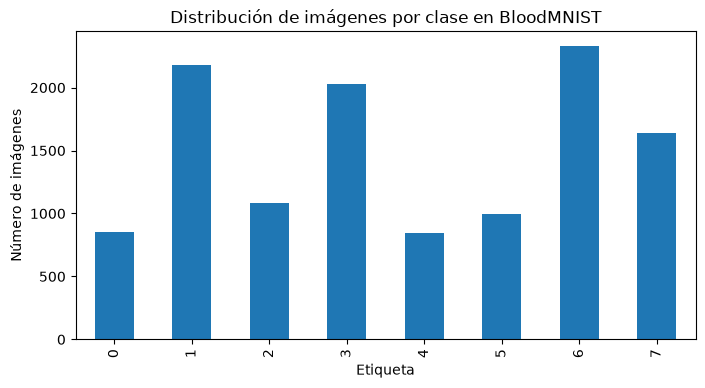

In [7]:
# Tamaño
X_train = train_dataset.imgs
y_train = train_dataset.labels.squeeze()

# Calcular frecuencia por clase
freq = pd.Series(y_train).value_counts().sort_index()

print("Frecuencia de imágenes por etiqueta:")
print(freq)

# Visualizar en gráfico de barras
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
freq.plot(kind="bar")
plt.xlabel("Etiqueta")
plt.ylabel("Número de imágenes")
plt.title("Distribución de imágenes por clase en BloodMNIST")
plt.show()

En la base de entrenamiento se tiene una representatividad mayor en los tipos de sangre 1,3 y 6. Los tipos 0, 4 y 5 con baja representatividad.

**Notas:**
Se revisó en otra programación la representatividad por tipo de sangre en las 3 bases (train, test y val) y la representativodad de los tipos de sangre es  similar.

In [17]:
# Extraer imágenes (X) y etiquetas (y)
# X_train = train_dataset.imgs
# y_train = train_dataset.labels.squeeze()
X_test = test_dataset.imgs
y_test = test_dataset.labels.squeeze()

# Transformación programática: Aplanar las imágenes de (N, 28, 28, 3) a (N, 2352)
# Usar -1 infiere automáticamente la dimensión restante, adaptándose a cualquier conjunto.
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Estandarización de variables
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# Codificación One-Hot para las etiquetas (preparación para Cross Entropy)
num_classes = len(np.unique(y_train))
y_train_onehot = np.eye(num_classes)[y_train]

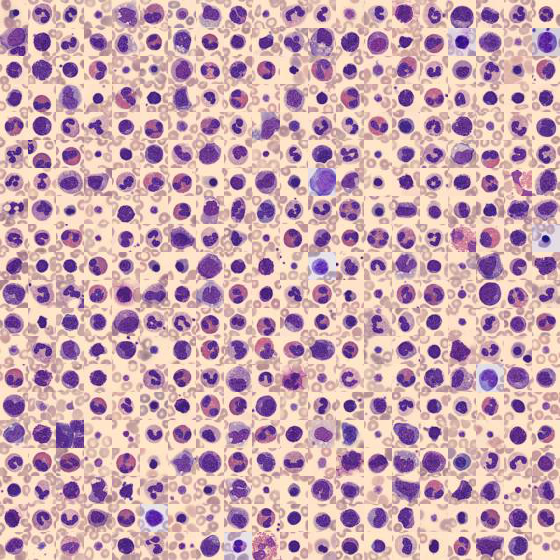

In [9]:
display(train_dataset.montage(length=20))

# Regresión logística: SGD

Época 0/50 - Loss: 1.0405
Época 10/50 - Loss: 0.5779
Época 20/50 - Loss: 0.4998
Época 30/50 - Loss: 0.4529
Época 40/50 - Loss: 0.4243
Época 49/50 - Loss: 0.4020


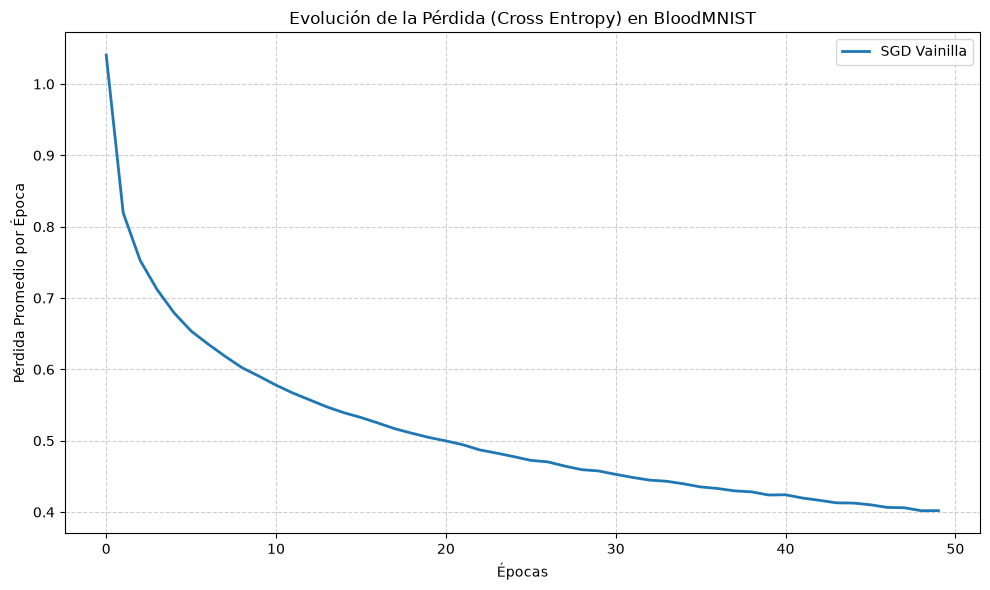

Exactitud (Accuracy) en el conjunto de prueba: 81.58%

Reporte de Clasificación (Desempeño por clase):
              precision    recall  f1-score   support

           0     0.6410    0.6148    0.6276       244
           1     0.9314    0.9567    0.9439       624
           2     0.8474    0.8392    0.8433       311
           3     0.6109    0.6805    0.6438       579
           4     0.8066    0.8066    0.8066       243
           5     0.6810    0.6690    0.6750       284
           6     0.9066    0.8018    0.8510       666
           7     0.9730    0.9979    0.9853       470

    accuracy                         0.8158      3421
   macro avg     0.7997    0.7958    0.7971      3421
weighted avg     0.8200    0.8158    0.8169      3421



In [10]:
class RegresionLogisticaSGD:
    def __init__(self, learning_rate=0.01, epochs=100, batch_size=64):
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        self.W = None
        self.b = None
        self.loss_history = []

    def _softmax(self, z):
        # Restar el máximo por estabilidad numérica (evitar overflow)
        z_safe = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_safe)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _compute_loss(self, y_true, y_pred):
        # Añadir un pequeño epsilon para evitar log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        # Cross entropy
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = y.shape[1]  # y viene en formato One-Hot

        # Inicialización programática de parámetros
        self.W = np.random.randn(n_features, n_classes) * 0.01
        self.b = np.zeros((1, n_classes))

        for epoch in range(self.epochs):
            # Mezclar los datos en cada época para la naturaleza estocástica
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            num_batches = 0

            # Iterar sobre mini-lotes
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                # 1. Forward pass (Puntajes y Activación)
                linear_output = np.dot(X_batch, self.W) + self.b
                y_pred = self._softmax(linear_output)

                # 2. Calcular gradientes
                # El gradiente de la cross entropy con softmax se simplifica a (y_pred - y_true)
                dW = np.dot(X_batch.T, (y_pred - y_batch)) / self.batch_size
                db = np.sum(y_pred - y_batch, axis=0, keepdims=True) / self.batch_size

                # 3. Actualización SGD vainilla (sin momentum, sin adaptación)
                # w = w - lr * gradiente
                self.W -= self.lr * dW
                self.b -= self.lr * db

                epoch_loss += self._compute_loss(y_batch, y_pred)
                num_batches += 1

            # Guardar la pérdida promedio de la época
            self.loss_history.append(epoch_loss / num_batches)

            # Imprimir progreso cada 10 épocas
            if epoch % 10 == 0 or epoch == self.epochs - 1:
                print(f"Época {epoch}/{self.epochs} - Loss: {self.loss_history[-1]:.4f}")

    def predict(self, X):
        linear_output = np.dot(X, self.W) + self.b
        y_pred = self._softmax(linear_output)
        return np.argmax(y_pred, axis=1)

# Instanciar el modelo vainilla (sin momentum)
modelo_sgd = RegresionLogisticaSGD(learning_rate=0.01, epochs=50, batch_size=128)

# Entrenar (usando las mismas variables escaladas y codificadas)
modelo_sgd.fit(X_train_scaled, y_train_onehot)

# Predecir sobre el conjunto de prueba
predicciones_sgd = modelo_sgd.predict(X_test_scaled)

# 1. Gráfica de evolución de la función de pérdida
plt.figure(figsize=(10, 6))
plt.plot(modelo_sgd.loss_history, label='SGD Vainilla', color='#1f77b4', linewidth=2)
plt.title('Evolución de la Pérdida (Cross Entropy) en BloodMNIST')
plt.xlabel('Épocas')
plt.ylabel('Pérdida Promedio por Época')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# 2. Evaluación cuantitativa y métricas en formato tabular
exactitud = accuracy_score(y_test, predicciones_sgd)
print(f"Exactitud (Accuracy) en el conjunto de prueba: {exactitud * 100:.2f}%\n")

# Generar una tabla de métricas (Precisión, Recall, F1-Score) para las 8 clases de células
reporte = classification_report(y_test, predicciones_sgd, digits=4)
print("Reporte de Clasificación (Desempeño por clase):")
print(reporte)

## Regresión logística: SGD + Momentum

In [11]:
class RegresionLogisticaMomentum:
    def __init__(self, learning_rate=0.01, momentum=0.9, epochs=100, batch_size=64):
        self.lr = learning_rate
        self.gamma = momentum  # Coeficiente de inercia
        self.epochs = epochs
        self.batch_size = batch_size
        self.W = None
        self.b = None
        self.loss_history = []

    def _softmax(self, z):
        # Restar el máximo por estabilidad numérica (evitar overflow)
        z_safe = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_safe)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _compute_loss(self, y_true, y_pred):
        # Añadir un pequeño epsilon para evitar log(0)
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        # Cross entropy
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = y.shape[1]  # Asumiendo que y viene en formato One-Hot

        # Inicialización programática de parámetros y velocidades
        self.W = np.random.randn(n_features, n_classes) * 0.01
        self.b = np.zeros((1, n_classes))

        v_W = np.zeros_like(self.W)
        v_b = np.zeros_like(self.b)

        for epoch in range(self.epochs):
            # Mezclar los datos en cada época para la naturaleza estocástica
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]

            epoch_loss = 0
            num_batches = 0

            # Iterar sobre mini-lotes
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i + self.batch_size]
                y_batch = y_shuffled[i:i + self.batch_size]

                # 1. Forward pass (Puntajes y Activación)
                linear_output = np.dot(X_batch, self.W) + self.b
                y_pred = self._softmax(linear_output)

                # 2. Calcular gradientes
                # El gradiente de la cross entropy con softmax se simplifica a (y_pred - y_true)
                dW = np.dot(X_batch.T, (y_pred - y_batch)) / self.batch_size
                db = np.sum(y_pred - y_batch, axis=0, keepdims=True) / self.batch_size

                # 3. Actualización con Momentum
                v_W = self.gamma * v_W + self.lr * dW
                v_b = self.gamma * v_b + self.lr * db

                self.W -= v_W
                self.b -= v_b

                epoch_loss += self._compute_loss(y_batch, y_pred)
                num_batches += 1

            # Guardar la pérdida promedio de la época
            self.loss_history.append(epoch_loss / num_batches)

            # Imprimir progreso cada 10 épocas
            if epoch % 10 == 0 or epoch == self.epochs - 1:
                print(f"Época {epoch}/{self.epochs} - Loss: {self.loss_history[-1]:.4f}")

    def predict(self, X):
        linear_output = np.dot(X, self.W) + self.b
        y_pred = self._softmax(linear_output)
        return np.argmax(y_pred, axis=1)

In [12]:
modelo_momentum = RegresionLogisticaMomentum(learning_rate=0.01, momentum=0.9, epochs=50, batch_size=128)

modelo_momentum.fit(X_train_scaled, y_train_onehot)

predicciones = modelo_momentum.predict(X_test_scaled)

Época 0/50 - Loss: 0.9736
Época 10/50 - Loss: 0.4419
Época 20/50 - Loss: 0.3878
Época 30/50 - Loss: 0.3400
Época 40/50 - Loss: 0.3206
Época 49/50 - Loss: 0.3128


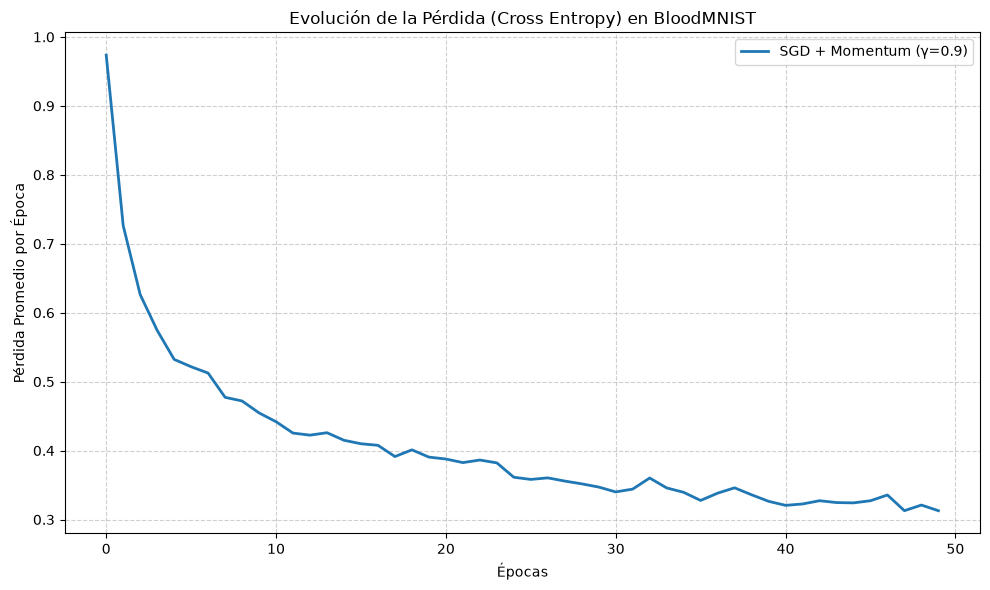

Exactitud (Accuracy) en el conjunto de prueba: 80.27%

Reporte de Clasificación (Desempeño por clase):
              precision    recall  f1-score   support

           0     0.6931    0.5369    0.6051       244
           1     0.9090    0.9439    0.9261       624
           2     0.7940    0.8553    0.8235       311
           3     0.5953    0.7064    0.6461       579
           4     0.8053    0.7490    0.7761       243
           5     0.6598    0.5669    0.6098       284
           6     0.8742    0.8138    0.8429       666
           7     0.9873    0.9915    0.9894       470

    accuracy                         0.8027      3421
   macro avg     0.7898    0.7705    0.7774      3421
weighted avg     0.8060    0.8027    0.8021      3421



In [13]:
plt.figure(figsize=(10, 6))
plt.plot(modelo_momentum.loss_history, label='SGD + Momentum (γ=0.9)', color='#1f77b4', linewidth=2)
plt.title('Evolución de la Pérdida (Cross Entropy) en BloodMNIST')
plt.xlabel('Épocas')
plt.ylabel('Pérdida Promedio por Época')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

exactitud = accuracy_score(y_test, predicciones)
print(f"Exactitud (Accuracy) en el conjunto de prueba: {exactitud * 100:.2f}%\n")

reporte = classification_report(y_test, predicciones, digits=4)
print("Reporte de Clasificación (Desempeño por clase):")
print(reporte)

## Comparacion de SGD Vainilla vs SGD + Momentum

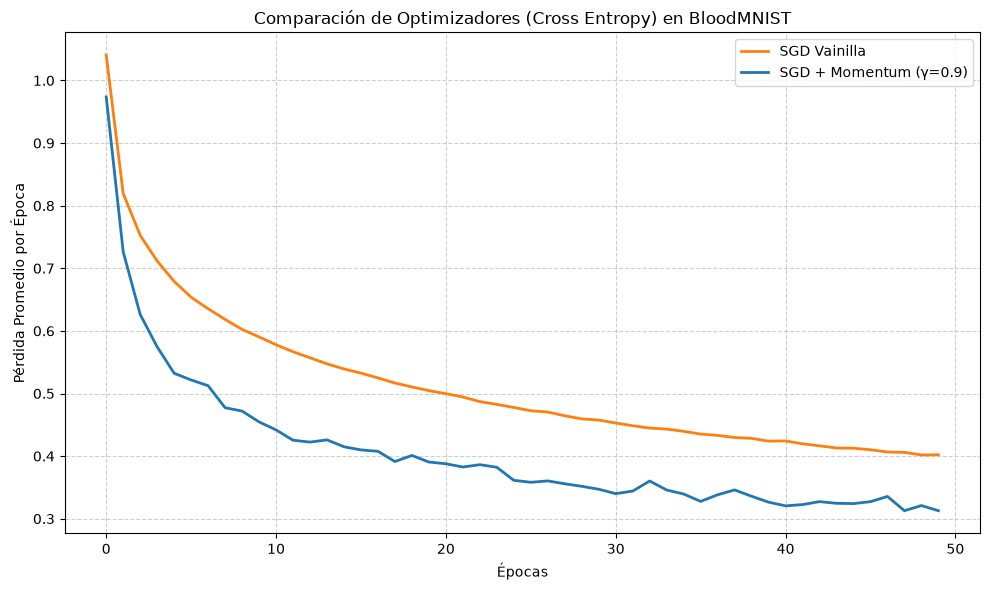

-------------------------
COMPARACIÓN DE ACCURACY
-------------------------
SGD Vainilla:      0.8158
SGD + Momentum:    0.8027
Diferencia:        0.0132

----------------------------------------
REPORTE DE CLASIFICACIÓN - SGD VAINILLA
----------------------------------------
              precision    recall  f1-score   support

           0     0.6410    0.6148    0.6276       244
           1     0.9314    0.9567    0.9439       624
           2     0.8474    0.8392    0.8433       311
           3     0.6109    0.6805    0.6438       579
           4     0.8066    0.8066    0.8066       243
           5     0.6810    0.6690    0.6750       284
           6     0.9066    0.8018    0.8510       666
           7     0.9730    0.9979    0.9853       470

    accuracy                         0.8158      3421
   macro avg     0.7997    0.7958    0.7971      3421
weighted avg     0.8200    0.8158    0.8169      3421


------------------------------------------
REPORTE DE CLASIFICACIÓN - S

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(modelo_sgd.loss_history, label='SGD Vainilla', color='#ff7f0e', linewidth=2)
plt.plot(modelo_momentum.loss_history, label='SGD + Momentum (γ=0.9)', color='#1f77b4', linewidth=2)
plt.title('Comparación de Optimizadores (Cross Entropy) en BloodMNIST')
plt.xlabel('Épocas')
plt.ylabel('Pérdida Promedio por Época')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Accuracy de cada modelo
acc_sgd = accuracy_score(y_test, predicciones_sgd)
acc_momentum = accuracy_score(y_test, predicciones)

print("-"*25)
print("COMPARACIÓN DE ACCURACY")
print("-"*25)
print(f"SGD Vainilla:      {acc_sgd:.4f}")
print(f"SGD + Momentum:    {acc_momentum:.4f}")
print(f"Diferencia:        {abs(acc_momentum - acc_sgd):.4f}")

# Classification report de cada modelo
print("\n" + "-"*40)
print("REPORTE DE CLASIFICACIÓN - SGD VAINILLA")
print("-"*40)
print(classification_report(y_test, predicciones_sgd, digits=4))

print("\n" + "-"*42)
print("REPORTE DE CLASIFICACIÓN - SGD + MOMENTUM")
print("-"*42)
print(classification_report(y_test, predicciones, digits=4))

# Conclusiones

El modelo de SGD + Momentum eceleró la convergencia del descenso de gradiente de manera significativamente mejor que SGD. Sin embargo, SGD Vainilla tuvo mayor estabilidad (sin crecimientos y descrecimientos repentinos) que son presentes en SGD + Momentum.

Se observa en la gráfica que la pérdida de 0.5 se presenta en SGD + Momentum en una iteración menor al 10 (alrededor de 7), mientras que en SGD se presenta en la iteración 20.

# **2. SGD en Scikit-learn**

# Descripción del problema
Aplicar  y explicar SGDRegressor SGD en scikit-learn (Teoría y Revisión documental).

#Teoría y Revisión documental:

*   Documentación:

    Se expone en la documentación oficial que el desempeño de SGDClassifier y SDGRegressor depende de los parámetros de la funció de pérdida, la tasa de aprendizaje, la regularización, el número de épocas, el escalamiento de las variables y el criterio de parada.  

*   **ESGDClassifier:** Entrena clasificadores lineales (SVM, regresión logística, perceptrón) mediante SGD. Soporta múltiples funciones de pérdida (hinge, log_loss, modified_huber) y penalizaciones (l1, l2, elasticnet).

*   **SGDRegressor:** Ajusta modelos de regresión lineal con SGD. Soporta pérdidas como squared_error, huber, y epsilon_insensitive. Es adecuado para problemas con grandes volúmenes de datos (>10,000 muestras).

*   Ventajas: Alta eficiencia y escalabilidad en problemas grandes y dispersos.

*   Desventajas: Sensibilidad al escalamiento de variables y necesidad de ajustar varios hiperparámetros

*   Explicación de elementos:

    1. Función de pérdida (loss): Define cómo se mide el error del modelo y es la métrica matemática que el algoritmo intenta minimizar durante el entrenamiento. Tenemos entonces:
    
        - Modelos de Clasificación: En SGDClassifier, usar loss='log_loss' implementa regresión logística, mientras que loss='hinge' implementa una Máquina de Vectores de Soporte (SVM).
      
        - Modelos de regresión: En SGDRegressor, loss='squared_error' minimiza los mínimos cuadrados ordinarios.

        Por lo que el tipo de función de pérdida, impacta en el tipo de modelo que se entrena.

    2. Tasa de aprendizaje (learning_rate): Controla el tamaño del paso que da el optimizador en cada iteración para actualizar los pesos. En scikit-learn, puede ser constante, óptima (invscaling: disminuye gradualmente basada en una heurística) o adaptativa (disminuye solo cuando el error deja de mejorar). Una tasa demasiado alta puede generar divergencia mientras que una demasiado baja, lograr una convergencia lenta.

    3. Regularización (penalty): Es un término de penalización que se añade a la función de pérdida para evitar el sobreajuste (overfitting), es controlada por el ´parámetro alpha. Scikit-learn permite penalizaciones:
    
    - L2: Ridge, encoge los pesos de manera uniforme,
    - L1: Lasso, forza algunos pesos a cero para selección de variables o
    - Elastic Net, es una una combinación de ambas.

    4. Número de épocas (max_iter): Representa el número máximo de veces que el algoritmo iterará sobre el conjunto de datos de entrenamiento completo. Si se alcanza este número, el algoritmo se detiene, incluso si no ha convergido idealmente. Pocas épocas podría generar un modelo subentrenado; demasiadas podría generar el riesgo de sobreajuste. Una recomendación inicial es max_iter ≈ 10^6 / n (donde n es el número de muestras).

    5. Escalamiento de variables: SGD es altamente sensible a la escala de las características (features). Si una variable tiene un rango de 0 a 1000 y otra de 0 a 1, el gradiente estará dominado por la primera, provocando oscilaciones severas. Por ello, es imperativo usar un escalador (como StandardScaler) o normalizar antes de entrenar. Es importante considerar que se debe aplicar el mismo escalamiento a las bases de entrenamiento (train), validación y prueba (test).

    6. Criterio de parada (tol / early_stopping): Es la condición lógica que le indica al algoritmo cuándo detenerse antes de alcanzar el número máximo de épocas. Generalmente, se detiene si la pérdida no mejora al menos una cantidad determinada (tolerancia = tol) durante un número específico de épocas continuas (n_iter_no_change). Esta cifra está limitada por max_iter.

*   Referencias:
https://scikit-learn.org/stable/modules/sgd.html

*   Comparación contra las notas de clase:
      En la clase se explicó la base matemática de los métodos de optimización (gradiente, Newton, BFGS).Se introdujo las variantes de SGD (momentum, AdaGrad, RMSProp, Adam) y se habló de mínimos "anchos" vs "angostos" y su relación con la generalización, mientras que en la documentación oficial encontramos la implementación práctica (SGDClassifier, SGDRegressor), eñ detalle en los parámetros específicos (loss, alpha, max_iter, learning_rate) y se explica cómo configurar el modelo en código.

# Metodología

SGD en scikit-learn en la base de imágenes de sangre (BloodMNIST)

# Programación

In [20]:

# ====> Método de Referencia: Regresión Logística Clásica
print("Entrenando Regresión Logística Tradicional...")
inicio_lr = time.time()
modelo_lr = LogisticRegression(solver='saga',
                               max_iter=1000,
                               random_state=42)

modelo_lr.fit(X_train_scaled, y_train)
fin_lr = time.time()

preds_lr = modelo_lr.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, preds_lr)

# ===> SGDClassifier (Regresión Logística con SGD)
print("Entrenando SGDClassifier...")
inicio_sgd = time.time()
# loss='log_loss' lo convierte en una regresión logística
modelo_sgd = SGDClassifier(loss='log_loss',
                           max_iter=1000,
                           tol=1e-3,
                           random_state=42)

modelo_sgd.fit(X_train_scaled, y_train)
fin_sgd = time.time()

preds_sgd = modelo_sgd.predict(X_test_scaled)
acc_sgd = accuracy_score(y_test, preds_sgd)

# Comparativa
print("\n--- Resultados de la Comparación ---")
print(f"Regresión Logística Tradicional:")
print(f"  Exactitud: {acc_lr*100:.2f}%")
print(f"  Tiempo de ejecución: {fin_lr - inicio_lr:.2f} segundos")
print("-" * 30)
print(f"SGDClassifier (log_loss):")
print(f"  Exactitud: {acc_sgd*100:.2f}%")
print(f"  Tiempo de ejecución: {fin_sgd - inicio_sgd:.2f} segundos")

Entrenando Regresión Logística Tradicional...


/home/emmanuel/Documentos/Proyects/Optimizacion_en_ML/Tarea_1/Proyecto-de-fin-de-modulo-7---Alfaro-Badillo-Cruz-Perez-Rupit/.venv/lib/python3.13/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Entrenando SGDClassifier...

--- Resultados de la Comparación ---
Regresión Logística Tradicional:
  Exactitud: 79.86%
  Tiempo de ejecución: 424.87 segundos
------------------------------
SGDClassifier (log_loss):
  Exactitud: 70.80%
  Tiempo de ejecución: 102.99 segundos


/home/emmanuel/Documentos/Proyects/Optimizacion_en_ML/Tarea_1/Proyecto-de-fin-de-modulo-7---Alfaro-Badillo-Cruz-Perez-Rupit/.venv/lib/python3.13/site-packages/sklearn/linear_model/_stochastic_gradient.py:741: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


Confusion matrix:
[[126   7   0  35   5   9  62   0]
 [  0 519   0   2   0   1 102   0]
 [  7   0 202   6   8   3  82   3]
 [ 36   7   1 215   5  58 257   0]
 [ 10   0   6  13 153   1  60   0]
 [  6   1   0  42   2 126 107   0]
 [  0  23   2  12   0   2 627   0]
 [  0   0   3   0   0   0  13 454]]


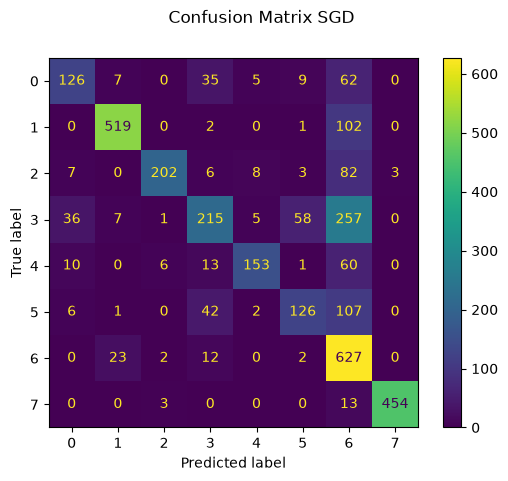


----------------------------------------
REPORTE DE CLASIFICACIÓN - SGD
----------------------------------------
              precision    recall  f1-score   support

           0     0.6811    0.5164    0.5874       244
           1     0.9318    0.8317    0.8789       624
           2     0.9439    0.6495    0.7695       311
           3     0.6615    0.3713    0.4757       579
           4     0.8844    0.6296    0.7356       243
           5     0.6300    0.4437    0.5207       284
           6     0.4786    0.9414    0.6346       666
           7     0.9934    0.9660    0.9795       470

    accuracy                         0.7080      3421
   macro avg     0.7756    0.6687    0.6977      3421
weighted avg     0.7611    0.7080    0.7063      3421



In [25]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, preds_sgd)
disp.figure_.suptitle("Confusion Matrix SGD")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()


print("\n" + "-"*40)
print("REPORTE DE CLASIFICACIÓN - SGD")
print("-"*40)
print(classification_report(y_test, preds_sgd, digits=4))

Confusion matrix:
[[142  10   2  64   3  16   7   0]
 [  6 577   1   5   3   5  27   0]
 [  6   1 264   8  18   2   9   3]
 [ 59  12  11 366  19  76  36   0]
 [  5   0  23  22 187   3   3   0]
 [  7   3   4  82   6 178   4   0]
 [  8  27  18  44  10   6 549   4]
 [  0   0   1   0   0   0   0 469]]


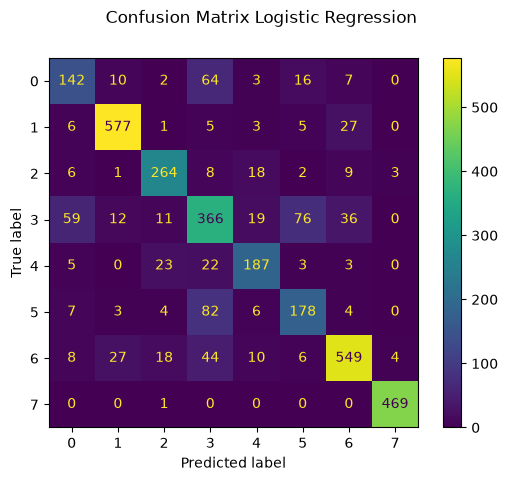


----------------------------------------
REPORTE DE CLASIFICACIÓN - Logistic Regression
----------------------------------------
              precision    recall  f1-score   support

           0     0.6094    0.5820    0.5954       244
           1     0.9159    0.9247    0.9203       624
           2     0.8148    0.8489    0.8315       311
           3     0.6193    0.6321    0.6256       579
           4     0.7602    0.7695    0.7648       243
           5     0.6224    0.6268    0.6246       284
           6     0.8646    0.8243    0.8440       666
           7     0.9853    0.9979    0.9915       470

    accuracy                         0.7986      3421
   macro avg     0.7740    0.7758    0.7747      3421
weighted avg     0.7988    0.7986    0.7985      3421



In [26]:
disp = metrics.ConfusionMatrixDisplay.from_predictions(y_test, preds_lr)
disp.figure_.suptitle("Confusion Matrix Logistic Regression")
print(f"Confusion matrix:\n{disp.confusion_matrix}")

plt.show()


print("\n" + "-"*40)
print("REPORTE DE CLASIFICACIÓN - Logistic Regression")
print("-"*40)
print(classification_report(y_test, preds_lr, digits=4))

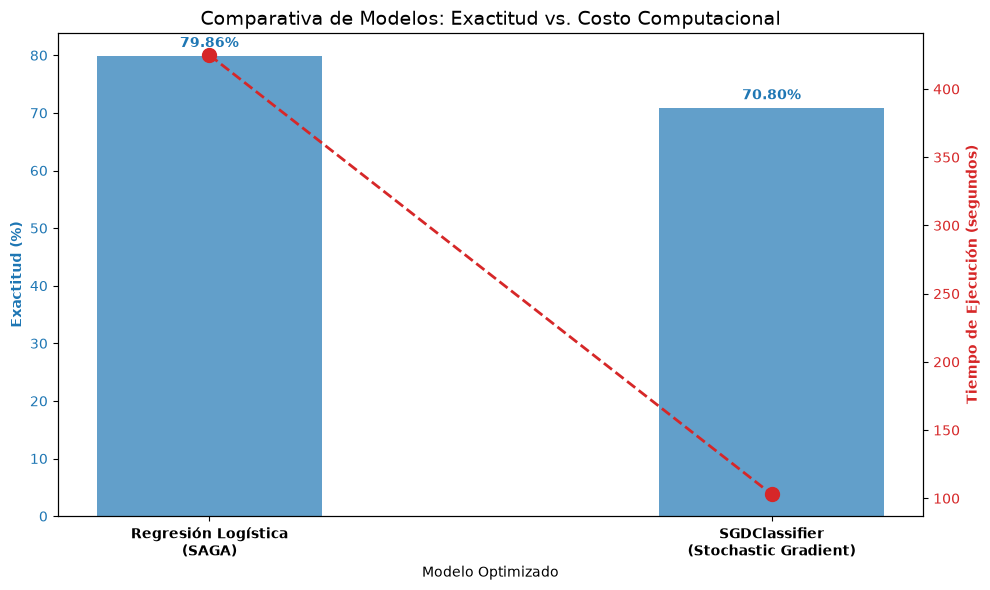

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, ax1 = plt.subplots(figsize=(10, 6))

modelos = ['Regresión Logística\n(SAGA)', 'SGDClassifier\n(Stochastic Gradient)']
exactitudes = [acc_lr * 100, acc_sgd * 100]
tiempos = [fin_lr - inicio_lr, fin_sgd - inicio_sgd]

# Eje Y Izquierdo: Gráfica de barras para la Exactitud
color_acc = '#1f77b4'
ax1.set_xlabel('Modelo Optimizado')
ax1.set_ylabel('Exactitud (%)', color=color_acc, fontweight='bold')
bars = ax1.bar([0, 1], exactitudes, color=color_acc, alpha=0.7, width=0.4)
ax1.tick_params(axis='y', labelcolor=color_acc)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(modelos, fontweight='bold')

# Etiquetar el porcentaje exacto sobre cada barra
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', 
             ha='center', va='bottom', color=color_acc, fontweight='bold')

# Eje Y Derecho: Gráfica de línea para el Tiempo
ax2 = ax1.twinx()  
color_time = '#d62728'
ax2.set_ylabel('Tiempo de Ejecución (segundos)', color=color_time, fontweight='bold')
ax2.plot([0, 1], tiempos, color=color_time, marker='o', linestyle='dashed', 
         linewidth=2, markersize=10, label='Tiempo')
ax2.tick_params(axis='y', labelcolor=color_time)

plt.title('Comparativa de Modelos: Exactitud vs. Costo Computacional', fontsize=14)
fig.tight_layout()
plt.show()


# Resultados
Se observa que al correr la comprobación del modelo en la base de prueba, la exactitud del modelo baja del 79% al 70%.

# Conclusiones y Comparación de los modelos  

XXXXX
Detalle en:
*   qué funciones de pérdida permite usar
*   qué parámetros son importantes
*   cómo se relaciona su funcionamiento con lo estudiado en clase.

### 3. SGD y sus variantes en redes neuronales, escoger uno de los siguientes:
#### 3.1. SGD y sus variantes para clasificación
Usar redes neuronales para un problema de clasificación de imágenes. El
objetivo es comparar el comportamiento de diferentes optimizadores en el
entrenamiento de una misma arquitectura de red neuronal.

Actividades
1. Construir una red neuronal convolucional sencilla para clasificación de
imágenes.
2. Mantener fija la arquitectura de la red y cambiar únicamente el opti-
mizador.
3. Comparar, según la paquetería utilizada, algunos de los siguientes mé-
todos:
SGD clásico;
SGD con momentum;
SGD con momentum de Nesterov;
AdaGrad;
RMSProp;
Adam;
AdamW, si está disponible.
4. Reportar la evolución de la función de pérdida durante el entrenamien-
to.
5. Reportar la exactitud en entrenamiento y validación.
6. Analizar si los optimizadores adaptativos convergen más rápido o si logran mejor desempeño final.

Preguntas a responderle the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1785884278.985129   21445 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/emmanuel/Documentos/Proyects/Optimizacion_en_ML/Tarea_1/Proyecto-de-fin-de-modulo-7---Alfaro-Badillo-Cruz-Perez-Rupit/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer,
1. ¿Qué optimizador reduce más rápido la función de pérdida?
2. ¿El optimizador con mejor desempeño en entrenamiento también es el
mejor en validación?
3. ¿Qué método parece más sensible a la elección de la tasa de aprendi-
zaje?

#### 3.2. SGD y sus variantes en redes neuronales para regresión
Usar redes neuronales para resolver un problema de regresión con datos reales. El objetivo es comparar el comportamiento de diferentes optimizadores en el entrenamiento de una red neuronal para regresión.

Actividades
1. Explorar la base de datos seleccionada.
2. Separar los datos en entrenamiento, validación y prueba.
3. Estandarizar las variables explicativas.
4. Construir una red neuronal multicapa sencilla.
5. Entrenar la misma arquitectura usando diferentes optimizadores:
SGD;
SGD con momentum;
AdaGrad;
RMSProp;
Adam;
AdamW, si está disponible.
6. Comparar los métodos usando métricas de regresión como:
MSE;
MAE;
RMSE;
R2.
7. Graficar la pérdida de entrenamiento y validación para cada optimiza-
dor.

Preguntas
1. ¿Qué optimizador converge más rápido?
2. ¿Qué optimizador logra menor error de validación?
3. ¿Hay evidencia de sobreajuste?
4. ¿Cómo afecta la tasa de aprendizaje al desempeño?

In [32]:
 
# Definir arquitectura CNN sencilla
def build_cnn(num_classes, input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape), # Correct way to define input shape in modern Keras
        layers.Conv2D(32, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

# Número de clases
num_classes = len(np.unique(y_train))
 
# Crear modelo base
cnn_model = build_cnn(num_classes)
 
# Compilar con SGD clásico
cnn_model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
 
# Entrenar
history_sgd = cnn_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

I0000 00:00:1785884276.400814   21445 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1785884278.985129   21445 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/emmanuel/Documentos/Proyects/Optimizacion_en_ML/Tarea_1/Proyecto-de-fin-de-modulo-7---Alfaro-Badillo-Cruz-Perez-Rupit/.venv/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1785884279.776445   21445 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call t

NameError: name 'X_val' is not defined

In [ ]:
# Prueba 2: Con un bucle para probar los otros modelos
def build_cnn(num_classes, input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation="relu", input_shape=input_shape),
        layers.MaxPooling2D((2,2)),
        layers.Conv2D(64, (3,3), activation="relu"),
        layers.MaxPooling2D((2,2)),
        layers.Flatten(),
        layers.Dense(64, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

In [ ]:
# Bucle para probar SGD clásico, SGD+Momentum, RMSProp y Adam.

# 1. Define the optimizers required by the assignment
optimizers = {
    "SGD Clásico": tf.keras.optimizers.SGD(learning_rate=0.01),
    "SGD Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "SGD Nesterov": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    "AdaGrad": tf.keras.optimizers.Adagrad(learning_rate=0.01),
    "RMSProp": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001),
    "AdamW": tf.keras.optimizers.AdamW(learning_rate=0.001)
}

# 2. Extract input shape and classes dynamically
input_shape = X_train_scaled.shape[1:] # Should be (28, 28, 3)
num_classes = len(np.unique(y_train))

# Dictionary to store the results
histories = {}

# 3. Training Loop
for name, opt in optimizers.items():
    print(f"--- Entrenando con {name} ---")
    
    # Must build a fresh model for every optimizer so weights reset
    model = build_cnn(num_classes, input_shape)
    
    model.compile(
        optimizer=opt, 
        loss="sparse_categorical_crossentropy", 
        metrics=["accuracy"]
    )
    
    # Train (using verbose=0 to keep your Jupyter Notebook clean)
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val, y_val),
        epochs=10, 
        batch_size=32,
        verbose=0 
    )
    
    histories[name] = history
    
    # Print final metrics for this optimizer
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"Finalizado -> Train Acc: {final_train_acc:.4f} | Val Acc: {final_val_acc:.4f}\n")

In [ ]:
# COmparación entre modelos
import matplotlib.pyplot as plt
 
plt.figure(figsize=(12,5))
 
# Pérdida
plt.subplot(1,2,1)
for name, history in histories.items():
    plt.plot(history.history["loss"], label=f"{name} - train")
    plt.plot(history.history["val_loss"], label=f"{name} - val")
plt.title("Evolución de la pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
 
# Exactitud
plt.subplot(1,2,2)
for name, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{name} - train")
    plt.plot(history.history["val_accuracy"], label=f"{name} - val")
plt.title("Evolución de la exactitud")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()
 
plt.show()

Programación:
Arquitectura simple:
Conv2D → MaxPooling → Flatten → Dense → Softmax.
Entrada: imágenes 128×128×3.
Salida: número de clases en BloodMNIST.
b) Mantener arquitectura fija Usaremos la misma red en todos los experimentos.
Lo único que cambia es el optimizador.
c) Optimizers a comparar SGD clásico
SGD + Momentum
RMSProp
Adam
AdamW (si está disponible en tu versión de TensorFlow/Keras)
d) Métricas y gráficas Evolución de la pérdida en entrenamiento y validación.
Evolución de la exactitud en entrenamiento y validación.
Comparación de convergencia y desempeño final.